In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [4]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

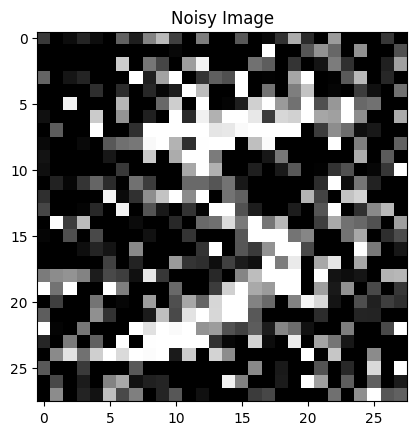

In [6]:
plt.imshow(x_train_noisy[0].reshape(28,28), cmap='gray')
plt.title("Noisy Image")
plt.show()

In [7]:
model = models.Sequential()

# Encoder
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2), padding='same'))

model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2,2), padding='same'))

# Decoder
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.UpSampling2D((2,2)))

model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.UpSampling2D((2,2)))

model.add(layers.Conv2D(1, (3,3), activation='sigmoid', padding='same'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam', loss='binary_crossentropy')

In [9]:
model.fit(x_train_noisy, x_train,
          epochs=5,
          batch_size=128,
          shuffle=True,
          validation_data=(x_test_noisy, x_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 256ms/step - loss: 0.1663 - val_loss: 0.1181
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 255ms/step - loss: 0.1138 - val_loss: 0.1090
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 252ms/step - loss: 0.1082 - val_loss: 0.1053
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 255ms/step - loss: 0.1053 - val_loss: 0.1038
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 253ms/step - loss: 0.1034 - val_loss: 0.1016


In [10]:
decoded_imgs = model.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


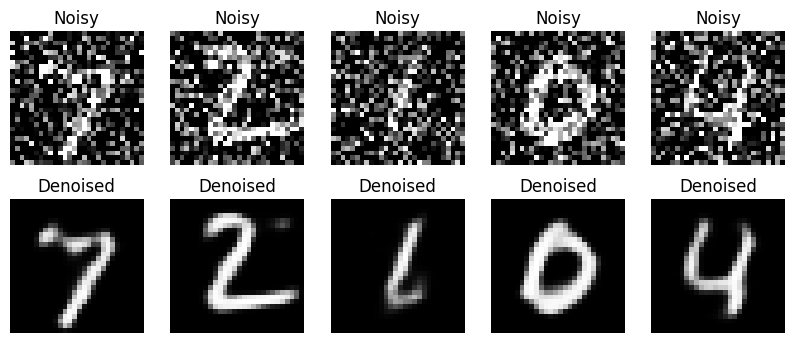

In [11]:
n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Noisy
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()